# Import Libraries


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

import warnings
warnings.filterwarnings("ignore")

# Load Datasets

In [2]:
brent = pd.read_csv("brent-daily.csv")

wti = pd.read_csv(
    "data.csv",
    comment="#"
)

real = pd.read_csv("real-oil-price.csv")

# Check Data

In [3]:
print(brent.head())

print(wti.head())

print(real.head())

        Date  Price
0  5/20/1987  18.63
1  5/21/1987  18.45
2  5/22/1987  18.55
3  5/25/1987  18.60
4  5/26/1987  18.63
       date  value            unit
0  1/2/1986  25.56  usd_per_barrel
1  1/3/1986  26.00  usd_per_barrel
2  1/6/1986  26.53  usd_per_barrel
3  1/7/1986  25.85  usd_per_barrel
4  1/8/1986  25.87  usd_per_barrel
       date  wti_nominal  cpi_index   wti_real
0  1/1/1986        18.95      109.9  57.587826
1  2/1/1986        13.23      109.7  40.278415
2  3/1/1986        10.25      109.1  31.377495
3  4/1/1986        13.38      108.7  41.109835
4  5/1/1986        14.30      109.0  43.815594


# Convert Dates

In [4]:
brent['Date'] = pd.to_datetime(brent['Date'])

wti['date'] = pd.to_datetime(wti['date'])

real['date'] = pd.to_datetime(real['date'])

# Rename Columns

In [5]:
wti = wti.rename(
    columns={
        'date':'Date',
        'value':'WTI_Price'
    }
)

real = real.rename(
    columns={
        'date':'Date'
    }
)

brent = brent.rename(
    columns={
        'Price':'Brent_Price'
    }
)

# Merge Datasets

In [6]:
df = pd.merge(
    brent,
    wti[['Date','WTI_Price']],
    on='Date',
    how='inner'
)

df = pd.merge(
    df,
    real,
    on='Date',
    how='left'
)

df.head()

,Date,Brent_Price,WTI_Price,wti_nominal,cpi_index,wti_real
0,1987-05-20,18.63,19.75,NaN,NaN,NaN
1,1987-05-21,18.45,19.95,NaN,NaN,NaN
2,1987-05-22,18.55,19.68,NaN,NaN,NaN
3,1987-05-26,18.63,19.35,NaN,NaN,NaN
4,1987-05-27,18.60,19.38,NaN,NaN,NaN


# Check Missing Values

In [7]:
df.isnull().sum()

Date              0
Brent_Price       0
WTI_Price         0
wti_nominal    9419
cpi_index      9419
wti_real       9419
dtype: int64

In [8]:
df.fillna(method='ffill', inplace=True)

In [9]:
df.isnull().sum()

Date           0
Brent_Price    0
WTI_Price      0
wti_nominal    7
cpi_index      7
wti_real       7
dtype: int64

# Basic Statistics

In [10]:
df.describe()

,Date,Brent_Price,WTI_Price,wti_nominal,cpi_index,wti_real
count,9713,9713.000000,9713.000000,9706.00000,9706.000000,9706.000000
mean,2006-10-18 13:59:16.264799744,51.194667,49.505980,49.52703,204.729026,76.494389
min,1987-05-20 00:00:00,9.100000,-36.980000,12.14000,113.500000,24.662440
25%,1997-01-08 00:00:00,19.530000,20.970000,21.16000,158.700000,49.443613
50%,2006-10-27 00:00:00,46.070000,45.800000,46.60000,203.100000,66.487742
75%,2016-07-06 00:00:00,74.840000,72.020000,71.89000,240.222000,98.658124
max,2026-05-11 00:00:00,143.950000,145.310000,127.35000,333.979000,197.633107
std,NaN,32.817780,29.357281,29.10802,55.718668,35.472813


# Brent Trend

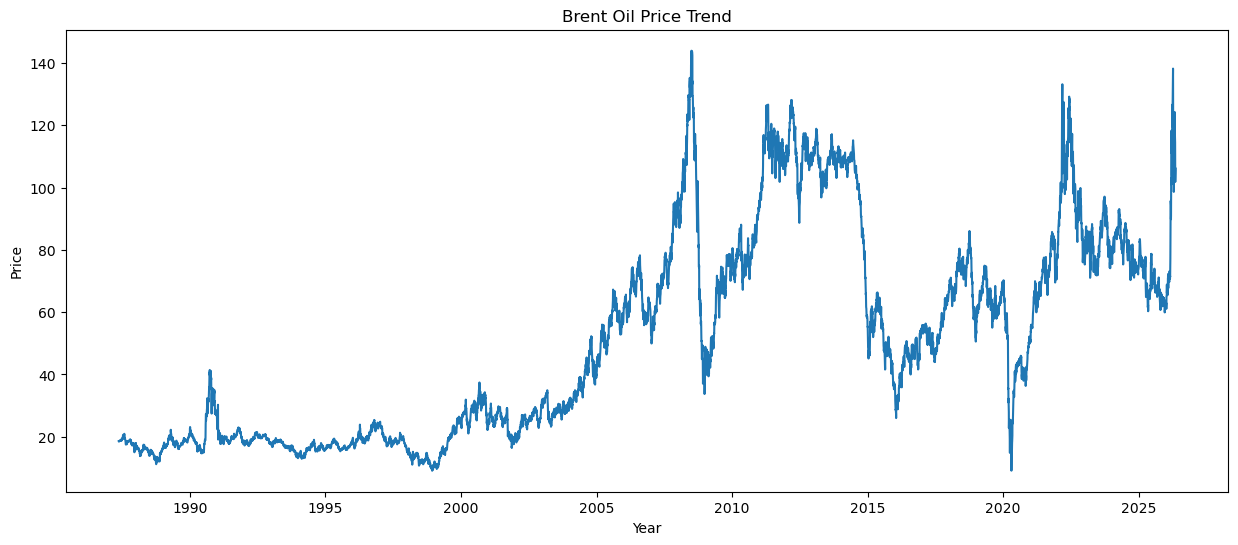

In [11]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Brent_Price']
)

plt.title("Brent Oil Price Trend")

plt.xlabel("Year")

plt.ylabel("Price")

plt.show()

# WTI Trend

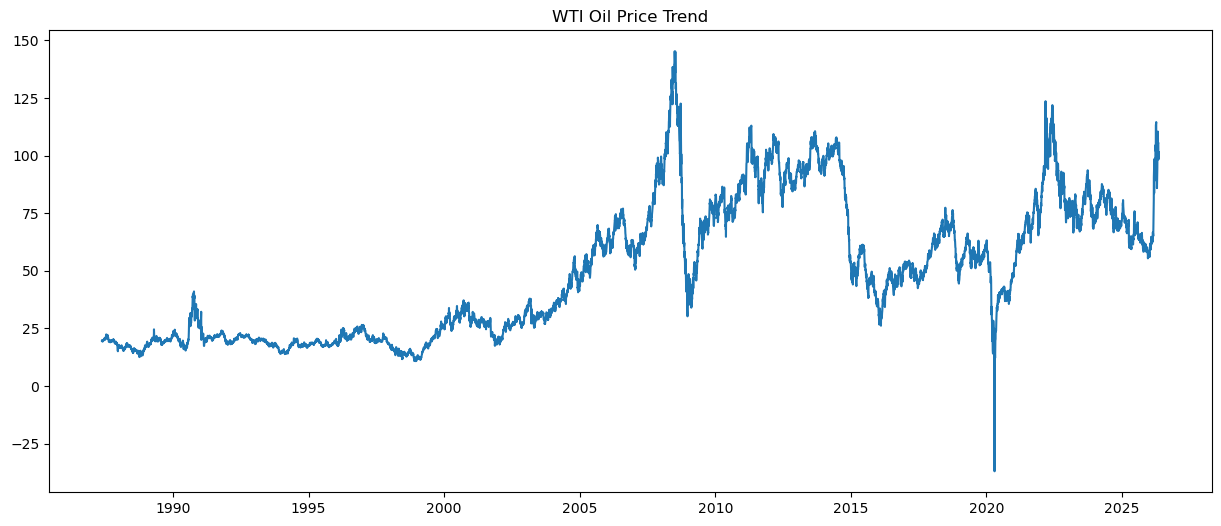

In [12]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['WTI_Price']
)

plt.title("WTI Oil Price Trend")

plt.show()

# Brent vs WTI

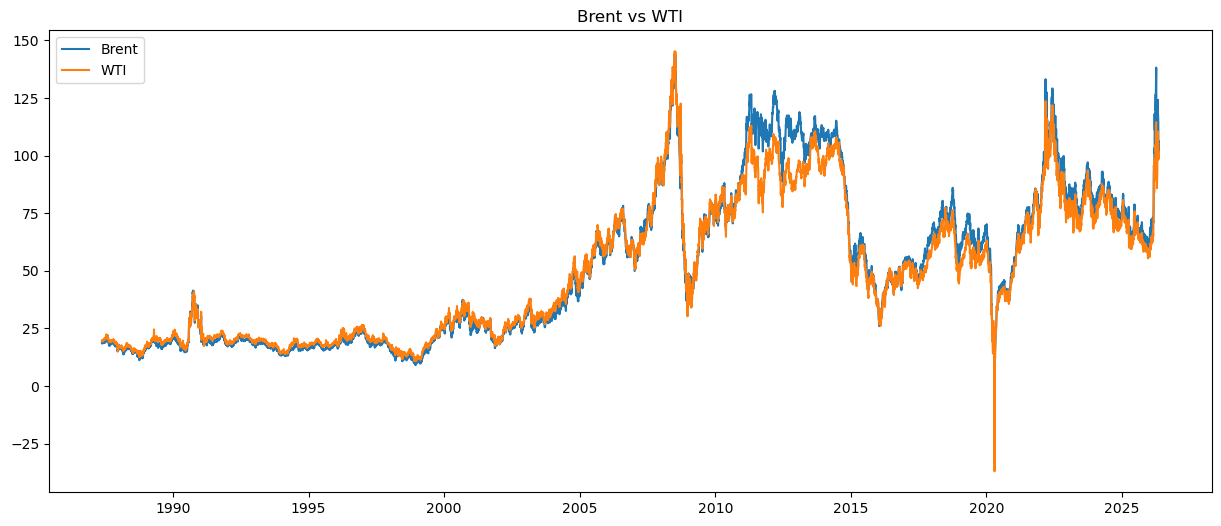

In [13]:
plt.figure(figsize=(15,6))

plt.plot(
    df['Date'],
    df['Brent_Price'],
    label='Brent'
)

plt.plot(
    df['Date'],
    df['WTI_Price'],
    label='WTI'
)

plt.legend()

plt.title("Brent vs WTI")

plt.show()

# Distribution

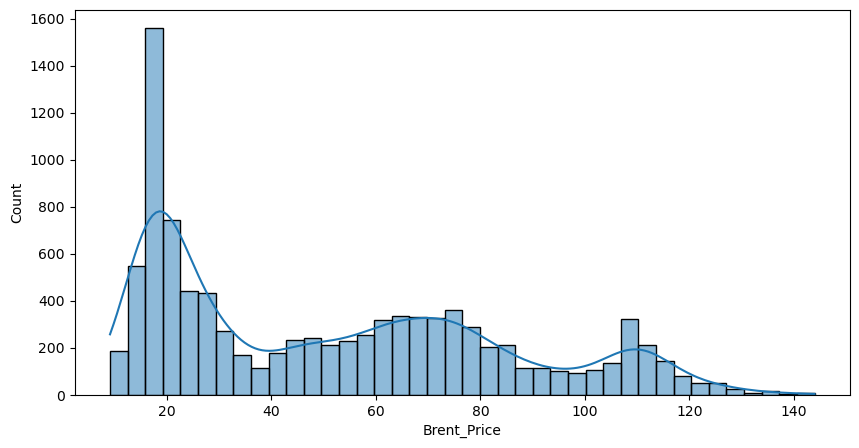

In [14]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Brent_Price'],
    bins=40,
    kde=True
)

plt.show()

# Correlation

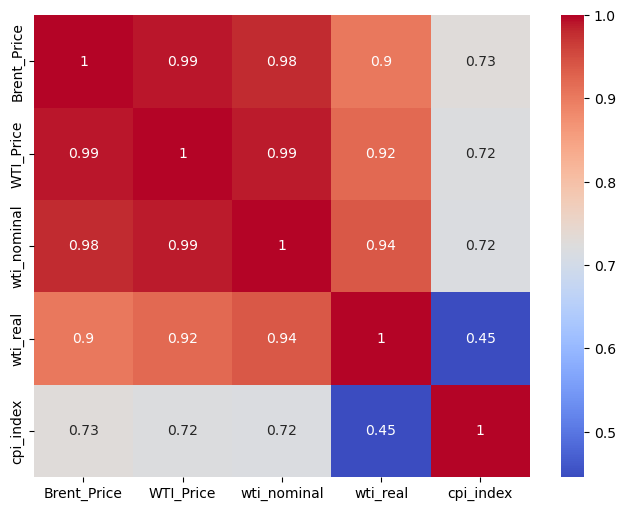

In [15]:
corr = df[
[
'Brent_Price',
'WTI_Price',
'wti_nominal',
'wti_real',
'cpi_index'
]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.show()

# Create Features

**Moving Averages**

In [17]:
df['MA7'] = df['Brent_Price'].rolling(7).mean()

df['MA30'] = df['Brent_Price'].rolling(30).mean()

**Daily Return**

In [18]:
df['Return'] = df['Brent_Price'].pct_change()

**Volatility**

In [19]:
df['Volatility'] = (
    df['Return']
    .rolling(30)
    .std()
)

**Lag Features**

In [20]:
df['Lag1'] = df['Brent_Price'].shift(1)

df['Lag7'] = df['Brent_Price'].shift(7)

df['Lag30'] = df['Brent_Price'].shift(30)

# Remove Nulls

In [21]:
df.dropna(inplace=True)

# Prepare ML Dataset

In [22]:
features = [
    'Lag1',
    'Lag7',
    'Lag30',
    'MA7',
    'MA30',
    'Volatility'
]

X = df[features]

y = df['Brent_Price']

# Train/Test Split

In [23]:
split = int(len(df)*0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

# Linear Regression

In [25]:
lr = LinearRegression()

lr.fit(X_train,y_train)

lr_pred = lr.predict(X_test)

In [26]:
mae = mean_absolute_error(
    y_test,
    lr_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        lr_pred
    )
)

r2 = r2_score(
    y_test,
    lr_pred
)

print("MAE:",mae)
print("RMSE:",rmse)
print("R2:",r2)

MAE: 1.3350578134341369
RMSE: 2.0404625793783717
R2: 0.9884328140873541


# Random Forest

In [27]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(
    X_test
)

In [28]:
print(
    mean_absolute_error(
        y_test,
        rf_pred
    )
)

1.4835914816726938


# XGBoost

In [29]:
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(
    X_test
)

In [30]:
print(
    mean_absolute_error(
        y_test,
        xgb_pred
    )
)

1.5910181394113239


In [37]:
forecast_df = pd.DataFrame({
    'Date': df.iloc[split:]['Date'],
    'Actual': y_test.values,
    'Predicted': xgb_pred
})

forecast_df.to_csv(
    "Forecast_Results.csv",
    index=False
)

forecast_df.head()

,Date,Actual,Predicted
7776,2018-06-26,73.58,72.919540
7777,2018-06-27,76.09,73.294952
7778,2018-06-28,76.26,76.190521
7779,2018-06-29,77.44,76.301796
7780,2018-07-02,76.71,77.287895


In [38]:
forecast_df.head()

,Date,Actual,Predicted
7776,2018-06-26,73.58,72.919540
7777,2018-06-27,76.09,73.294952
7778,2018-06-28,76.26,76.190521
7779,2018-06-29,77.44,76.301796
7780,2018-07-02,76.71,77.287895


# Actual vs Predicted

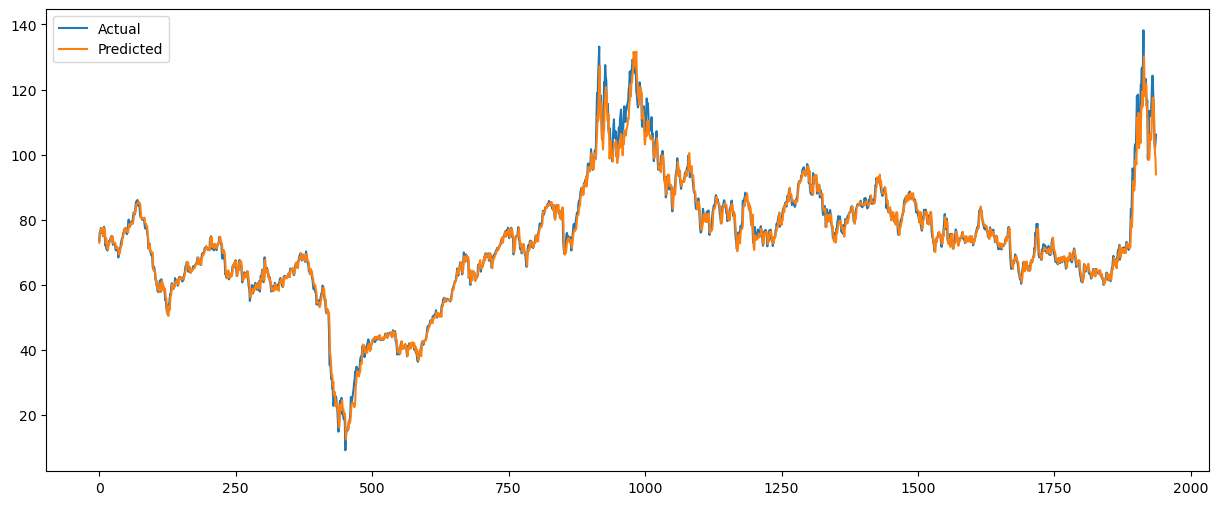

In [31]:
plt.figure(figsize=(15,6))

plt.plot(
    y_test.values,
    label='Actual'
)

plt.plot(
    xgb_pred,
    label='Predicted'
)

plt.legend()

plt.show()

# Trend Classification (AI Component)

In [32]:
df['Market_Trend'] = np.where(
    df['Return'] > 0.02,
    'Bullish',
    np.where(
        df['Return'] < -0.02,
        'Bearish',
        'Stable'
    )
)

In [33]:
df['Market_Trend'].value_counts()

Market_Trend
Stable     6889
Bullish    1425
Bearish    1369
Name: count, dtype: int64

# Save Final Dataset

In [34]:
df.to_csv(
    "Oil_Project_Final.csv",
    index=False
)